# 03. LLM Fine-Tuning and LoRA

This notebook studies how a pretrained causal language model can be adapted to a downstream instruction-style task. The focus is not merely on calling PEFT utilities; it first develops the logic of full fine-tuning, parameter-efficient fine-tuning, and the low-rank update used by LoRA.

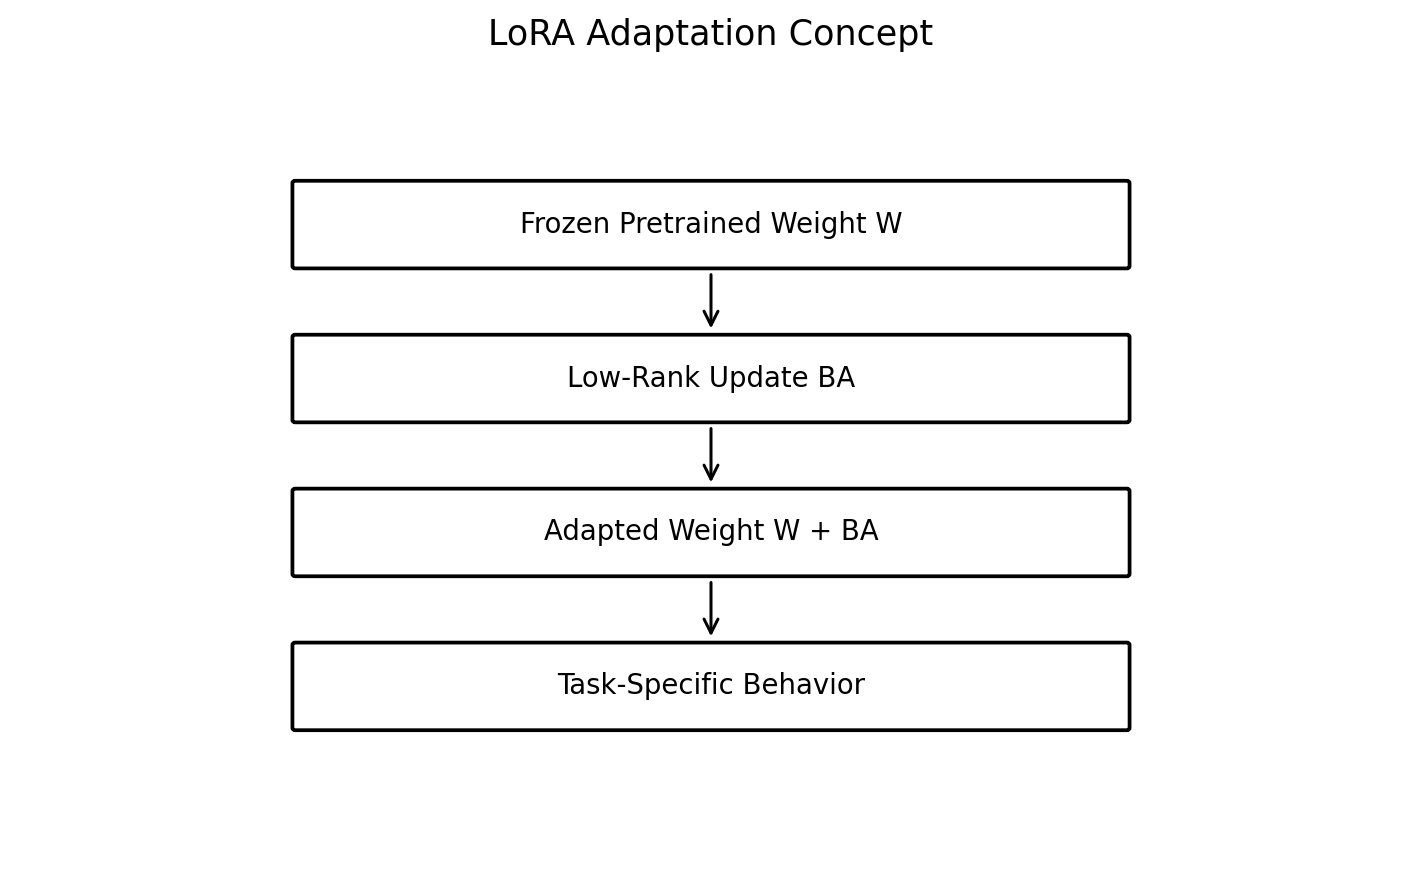

## Learning Objectives

- distinguish pretraining, prompting, instruction tuning, and fine-tuning,
- explain why full fine-tuning is expensive,
- derive the basic LoRA parameterization,
- understand rank, alpha, dropout, and target modules,
- inspect an instruction-style dataset before training,
- establish a base-model baseline,
- apply LoRA using PEFT,
- count total and trainable parameters,
- train a compact causal model,
- compare base and adapted outputs,
- discuss when LoRA is useful and when it is insufficient.

## 1. Pretraining vs Fine-Tuning vs Prompting

**Pretraining** learns broad language patterns from a large corpus.

**Prompting** changes the input while keeping model parameters frozen.

**Fine-tuning** updates model parameters using examples from a downstream task.

**Instruction tuning** is fine-tuning on instruction-response examples so the model learns a response format and task-following behavior.

## 2. Why Full Fine-Tuning Is Expensive

If a model has billions of parameters, full fine-tuning requires gradients and optimizer states for the entire network. This increases accelerator memory, storage, and training cost.

Parameter-efficient fine-tuning (PEFT) keeps most pretrained parameters frozen and trains a much smaller set of task-specific parameters.

## 3. LoRA Mathematics

For a pretrained weight matrix $W$, LoRA keeps $W$ frozen and learns a low-rank update:

$$
W' = W + \Delta W
$$

with

$$
\Delta W = BA.
$$

If $W \in \mathbb{R}^{d 	imes k}$, LoRA chooses a rank $r$ such that

$$
r \ll \min(d,k).
$$

Instead of learning all $dk$ values in a new dense matrix, the update learns approximately $r(d+k)$ values in two smaller matrices.

### LoRA Hyperparameters

- **rank (`r`)**: capacity of the low-rank update,
- **alpha**: scaling factor applied to the update,
- **dropout**: regularization applied within the adapter path,
- **target modules**: model layers that receive LoRA adapters.

A larger rank increases adaptation capacity but also increases trainable parameters.

## 4. Install/Import Libraries

In [1]:
# Uncomment this line in a fresh Colab environment if needed.
# !pip install -q transformers datasets peft accelerate

In [2]:
import random

import pandas as pd
import torch

from datasets import Dataset
from peft import LoraConfig
from peft import TaskType
from peft import get_peft_model
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer
from transformers import DataCollatorForLanguageModeling
from transformers import Trainer
from transformers import TrainingArguments

print("PyTorch version:")
print(torch.__version__)

PyTorch version:
2.11.0+cpu


## 5. Reproducibility and Device

In [3]:
SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:")
print(device)

Device:
cpu


## 6. Create a Small Instruction Dataset

For a portfolio notebook, a compact self-contained dataset makes every training example easy to inspect. The examples below focus on manufacturing and operations language so the task is concrete.

For a larger experiment, the same workflow can be applied to public instruction datasets such as Alpaca-style data.

In [4]:
records = [
    {
        "instruction": "Explain takt time in one sentence.",
        "response": "Takt time is the maximum average time available to produce one unit while meeting customer demand."
    },
    {
        "instruction": "What does WIP mean in manufacturing?",
        "response": "WIP means work in process, the inventory of items that have entered production but are not yet finished."
    },
    {
        "instruction": "Define a digital twin.",
        "response": "A digital twin is a dynamic digital representation of a physical system that is updated using data and used for analysis, prediction, or decision support."
    },
    {
        "instruction": "What is discrete-event simulation?",
        "response": "Discrete-event simulation models a system as a sequence of events that change the system state at specific points in simulated time."
    },
    {
        "instruction": "What is an AGV?",
        "response": "An automated guided vehicle is a mobile material-handling vehicle that follows programmed navigation logic to move loads within a facility."
    },
    {
        "instruction": "Why is bottleneck analysis important?",
        "response": "Bottleneck analysis identifies the resource or process that most constrains system throughput and therefore limits overall performance."
    },
    {
        "instruction": "What is throughput?",
        "response": "Throughput is the rate at which a system completes or produces units over a specified period of time."
    },
    {
        "instruction": "Define utilization.",
        "response": "Utilization is the fraction of available time that a resource is busy performing productive or modeled work."
    },
    {
        "instruction": "What is reinforcement learning?",
        "response": "Reinforcement learning is a learning framework in which an agent selects actions in an environment and learns from rewards generated by the resulting state transitions."
    },
    {
        "instruction": "Why can simulation support optimization?",
        "response": "Simulation can estimate the performance of candidate decisions under realistic variability, allowing optimization methods to search for decisions that perform well in the simulated system."
    },
    {
        "instruction": "What is congestion in a material-handling system?",
        "response": "Congestion occurs when vehicles or loads interfere with one another so that movement is delayed, blocked, or rerouted."
    },
    {
        "instruction": "Define order fulfillment rate.",
        "response": "Order fulfillment rate measures the proportion of required customer demand that is successfully completed within the defined service requirement."
    }
]

raw_dataframe = pd.DataFrame(records)

print("Number of examples:")
print(len(raw_dataframe))

print()
print("Columns:")
print(raw_dataframe.columns.tolist())

raw_dataframe

Number of examples:
12

Columns:
['instruction', 'response']


,instruction,response
0,Explain takt time in one sentence.,Takt time is the maximum average time availabl...
1,What does WIP mean in manufacturing?,"WIP means work in process, the inventory of it..."
2,Define a digital twin.,A digital twin is a dynamic digital representa...
3,What is discrete-event simulation?,Discrete-event simulation models a system as a...
4,What is an AGV?,An automated guided vehicle is a mobile materi...
5,Why is bottleneck analysis important?,Bottleneck analysis identifies the resource or...
6,What is throughput?,Throughput is the rate at which a system compl...
7,Define utilization.,Utilization is the fraction of available time ...
8,What is reinforcement learning?,Reinforcement learning is a learning framework...
9,Why can simulation support optimization?,Simulation can estimate the performance of can...


## 7. Format Instruction-Response Training Text

Causal language models train on token sequences. We therefore convert each row into one consistent text template.

In [5]:
def format_record(record):
    text = (
        "### Instruction:\n"
        + record["instruction"]
        + "\n\n### Response:\n"
        + record["response"]
    )

    return text

formatted_examples = []

for record in records:
    formatted_text = format_record(record)
    formatted_examples.append(formatted_text)

print(formatted_examples[0])

### Instruction:
Explain takt time in one sentence.

### Response:
Takt time is the maximum average time available to produce one unit while meeting customer demand.


## 8. Create Training and Validation Splits

In [6]:
train_records = records[:10]
validation_records = records[10:]

train_dataset = Dataset.from_list(train_records)
validation_dataset = Dataset.from_list(validation_records)

print("Training examples:")
print(len(train_dataset))

print()
print("Validation examples:")
print(len(validation_dataset))

Training examples:
10

Validation examples:
2


## 9. Load a Very Small Causal Model

`sshleifer/tiny-gpt2` is intentionally tiny. It is selected so LoRA mechanics can be demonstrated quickly on limited hardware. It is not expected to have strong language quality.

For a stronger portfolio experiment with more compute, the same pipeline can be repeated with a larger instruction-capable causal model.

In [7]:
model_name = "sshleifer/tiny-gpt2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(model_name)

print("Tokenizer vocabulary size:")
print(tokenizer.vocab_size)

print()
print("Model class:")
print(type(base_model))

config.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/90.0 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/29 [00:00<?, ?it/s]

[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors: reconstructing file:   0%|          |  0.00B / 2.51MB            

model.safetensors: downloading bytes:           |  0.00B            

Tokenizer vocabulary size:
50257

Model class:
<class 'transformers.models.gpt2.modeling_gpt2.GPT2LMHeadModel'>


## 10. Inspect Tokenization Before Training

In [8]:
example_text = formatted_examples[0]

encoded_example = tokenizer(
    example_text,
    truncation=True,
    max_length=128
)

print("Original training text:")
print(example_text)

print()
print("Number of tokens:")
print(len(encoded_example["input_ids"]))

print()
print("First 30 token IDs:")
print(encoded_example["input_ids"][:30])

Original training text:
### Instruction:
Explain takt time in one sentence.

### Response:
Takt time is the maximum average time available to produce one unit while meeting customer demand.

Number of tokens:
39

First 30 token IDs:
[21017, 46486, 25, 198, 18438, 391, 256, 461, 83, 640, 287, 530, 6827, 13, 198, 198, 21017, 18261, 25, 198, 51, 461, 83, 640, 318, 262, 5415, 2811, 640, 1695]


## 11. Tokenize the Complete Dataset

In [9]:
MAX_LENGTH = 160


def tokenize_record(example):
    formatted_text = format_record(example)

    tokenized = tokenizer(
        formatted_text,
        truncation=True,
        max_length=MAX_LENGTH,
        padding="max_length"
    )

    return tokenized

train_tokenized = train_dataset.map(tokenize_record)
validation_tokenized = validation_dataset.map(tokenize_record)

print(train_tokenized)

Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'response', 'input_ids', 'attention_mask'],
    num_rows: 10
})


## 12. Establish a Base-Model Baseline

Before adaptation, use exactly the same prompt format that will be used after LoRA training.

In [10]:
def generate_response(model, instruction, max_new_tokens=50):
    prompt_text = (
        "### Instruction:\n"
        + instruction
        + "\n\n### Response:\n"
    )

    inputs = tokenizer(
        prompt_text,
        return_tensors="pt"
    )

    inputs = {
        key: value.to(next(model.parameters()).device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    return generated_text

base_model = base_model.to(device)
base_model.eval()

baseline_instruction = "Define a digital twin."

baseline_output = generate_response(
    base_model,
    baseline_instruction
)

print(baseline_output)

### Instruction:
Define a digital twin.

### Response:
 stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs


## 13. Count Parameters Before LoRA

In [11]:
def count_parameters(model):
    total = 0
    trainable = 0

    for parameter in model.parameters():
        number = parameter.numel()
        total = total + number

        if parameter.requires_grad:
            trainable = trainable + number

    percentage = 100 * trainable / total

    return total, trainable, percentage

base_total, base_trainable, base_percentage = count_parameters(base_model)

print("Total parameters:")
print(f"{base_total:,}")

print()
print("Trainable parameters before freezing/adaptation:")
print(f"{base_trainable:,}")

print()
print("Trainable percentage:")
print(round(base_percentage, 4), "%")

Total parameters:
102,714

Trainable parameters before freezing/adaptation:
102,714

Trainable percentage:
100.0 %


## 14. Identify LoRA Target Modules

GPT-2 implementations use a combined projection module named `c_attn` inside each attention block. We attach LoRA adapters to this projection.

In [12]:
for name, module in base_model.named_modules():
    if "c_attn" in name:
        print(name, "->", type(module))

transformer.h.0.attn.c_attn -> <class 'transformers.pytorch_utils.Conv1D'>
transformer.h.1.attn.c_attn -> <class 'transformers.pytorch_utils.Conv1D'>


## 15. Configure LoRA

In [13]:
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
    target_modules=["c_attn"]
)

print(lora_config)

LoraConfig(task_type=<TaskType.CAUSAL_LM: 'CAUSAL_LM'>, peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, peft_version='0.20.0', base_model_name_or_path=None, revision=None, inference_mode=False, r=8, target_modules={'c_attn'}, exclude_modules=None, lora_alpha=16, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, lora_ga_config=None, use_dora=False, velora_config=None, alora_invocation_tokens=None, use_qalora=False, qalora_group_size=16, monteclora_config=None, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None, use_bdlora=None, arrow_config=None, ensure_weight_tying=False)


## 16. Apply LoRA Adapters

### Upgrade `torchao`

The previous error indicates an incompatible version of `torchao`. Let's upgrade it to meet the `peft` library's requirements. You might need to restart the runtime after this installation for the changes to take effect.

In [15]:
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 35.7 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [16]:
peft_model = get_peft_model(
    base_model,
    lora_config
)

peft_model.print_trainable_parameters()

trainable params: 128 || all params: 102,842 || trainable%: 0.1245


/usr/local/lib/python3.13/dist-packages/peft/tuners/lora/layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


### Verify the Trainable Fraction

In [17]:
lora_total, lora_trainable, lora_percentage = count_parameters(peft_model)

print("Total parameters after adding LoRA:")
print(f"{lora_total:,}")

print()
print("Trainable parameters:")
print(f"{lora_trainable:,}")

print()
print("Trainable percentage:")
print(round(lora_percentage, 4), "%")

Total parameters after adding LoRA:
102,842

Trainable parameters:
128

Trainable percentage:
0.1245 %


## 17. Data Collation for Causal Language Modeling

For causal language modeling, the labels are the same token sequence shifted internally by the model's loss function. The collator also handles padding correctly.

In [18]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

## 18. Training Configuration

The settings below are intentionally small for a portfolio demonstration. For serious adaptation, increase dataset size, use a stronger base model, and tune the schedule carefully.

In [19]:
training_arguments = TrainingArguments(
    output_dir="outputs/lora_tiny_gpt2",
    num_train_epochs=8,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    learning_rate=5e-4,
    logging_steps=2,
    save_strategy="no",
    report_to="none",
    seed=SEED
)

print(training_arguments)

TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_in_order=True,
dataloader_multiprocessing_context=None,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=False,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_star

## 19. Create the Trainer

In [21]:
trainer = Trainer(
    model=peft_model,
    args=training_arguments,
    train_dataset=train_tokenized,
    eval_dataset=validation_tokenized,
    data_collator=data_collator
)

## 20. Fine-Tune the LoRA Adapters

In [22]:
training_result = trainer.train()

print(training_result)

/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
2,10.549854
4,10.552349
6,10.552376
8,10.547553
10,10.538837
12,10.559480
14,10.548128
16,10.517998
18,10.558666
20,10.561804


TrainOutput(global_step=40, training_loss=10.548515510559081, metrics={'train_runtime': 40.8954, 'train_samples_per_second': 1.956, 'train_steps_per_second': 0.978, 'total_flos': 21504000.0, 'train_loss': 10.548515510559081, 'epoch': 8.0})


## 21. Evaluate Validation Loss

In [23]:
evaluation_result = trainer.evaluate()

evaluation_result

Training Loss,Validation Loss,Step
10.548235,10.561280,40


{'eval_loss': 10.561280250549316}

## 22. Compare Base and Adapted Model Outputs

Because the base model object has been wrapped by PEFT, the most useful comparison in a small notebook is to preserve the baseline text captured before training and compare it with the adapted output after training.

In [24]:
peft_model.eval()

adapted_output = generate_response(
    peft_model,
    baseline_instruction
)

print("BASELINE OUTPUT")
print("-" * 80)
print(baseline_output)

print()
print("LORA-ADAPTED OUTPUT")
print("-" * 80)
print(adapted_output)

BASELINE OUTPUT
--------------------------------------------------------------------------------
### Instruction:
Define a digital twin.

### Response:
 stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs

LORA-ADAPTED OUTPUT
--------------------------------------------------------------------------------
### Instruction:
Define a digital twin.

### Response:
 stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs sta

## 23. Test Several Instructions

In [25]:
test_instructions = [
    "What is throughput?",
    "Why is bottleneck analysis important?",
    "What is reinforcement learning?",
    "Explain how simulation can support optimization."
]

for instruction in test_instructions:
    output = generate_response(
        peft_model,
        instruction,
        max_new_tokens=60
    )

    print("Instruction:")
    print(instruction)
    print()
    print("Generated response:")
    print(output)
    print("=" * 90)

Instruction:
What is throughput?

Generated response:
### Instruction:
What is throughput?

### Response:
 factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors factors
Instruction:
Why is bottleneck analysis important?

Generated response:
### Instruction:
Why is bottleneck analysis important?

### Response:
 stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stairs stai

## 24. Qualitative Evaluation Framework

For instruction-style adaptation, useful qualitative questions include:

- Does the model answer the requested task?
- Does it follow the expected response format?
- Does it reproduce target terminology correctly?
- Does it overfit and copy memorized training phrases?
- Does it hallucinate when the instruction is outside the tiny dataset?

A larger project should complement this with task-specific quantitative metrics and a held-out test set.

## 25. What LoRA Changes — and What It Does Not

### Advantages

- dramatically reduces trainable parameter count,
- lowers memory and storage cost relative to full fine-tuning,
- allows multiple task adapters to share one frozen base model,
- works well for many domain and instruction adaptation settings.

### Limitations

- it does not give the model factual knowledge it cannot represent well,
- a tiny or weak base model remains limited after adaptation,
- poor or narrow data can cause overfitting,
- adapter hyperparameters and target modules still require tuning,
- fine-tuning is not a replacement for retrieval when knowledge changes frequently.

## 26. Full Fine-Tuning vs LoRA vs RAG

| Method | Changes model weights? | Best use |
|---|---:|---|
| Prompting | No | steer behavior with context |
| Full fine-tuning | Yes, most/all | deep task adaptation when compute permits |
| LoRA / PEFT | Yes, small adapter set | efficient behavior/domain adaptation |
| RAG | Usually no model update | inject external or changing knowledge |

This distinction motivates the next notebook: retrieval-augmented generation.

## Key Takeaways

1. Fine-tuning changes model parameters; prompting does not.
2. Full fine-tuning becomes expensive as parameter count grows.
3. LoRA freezes the pretrained matrix and learns a low-rank update.
4. Rank controls adapter capacity and parameter count.
5. PEFT makes the trainable fraction of a model very small.
6. A baseline must be recorded before adaptation.
7. A small educational dataset demonstrates mechanics but is not evidence of broad generalization.
8. Fine-tuning adapts behavior; RAG is better suited to retrieving external or frequently changing knowledge.